In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path
from collections import defaultdict
import re

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

from utils.plots import calculate_metrics, calculate_accuracy
from utils.tools import get_config, collect_jobs, prettify_table, format_table, aggregate_results
from utils.constants import PRED_COLS

In [3]:
def order_suites(strings):
    return sorted(strings, key=lambda s: (
        s.split('-')[2],  # implicit-excplict
        s.split('-')[0],  # num demos
        s.split('-')[1],  # demo type
    ))

def order_models(strings):
    return sorted(strings, key=lambda s: (
        int(s.split('-')[1][:-1]),  # Param count, B dropped
        #s.split('-')[0],  # Model name
    ), reverse=True)

def capitalize(s):
    return s[0].upper() + s[1:]


In [4]:
def format_model_name(name):
    parts = name.split("-")
    match = re.search(r"\d{1,2}B", name)
    return f"{parts[0]}-{match.group(0)}" if match else name

def get_jobs_per_model_and_suite(jobs):
    
    print(f"Processing {len(jobs)} jobs.")
    # Dict of model -> suite -> seed -> jobId
    table = defaultdict(lambda: defaultdict(lambda: defaultdict(str)))
    for job in jobs:
        config = get_config(job["config_json"])
        model = config.get("model").split("/")[1]
        suite = get_suite(config)
        seed = config["seed"]

        table[model][suite][seed] = config.get("jobid")

    return table

def get_suite(cfg):

    #print(cfg)
    
    n_demos = cfg["number_of_demonstrations"]

    type_demos = (
        "non" 
        if n_demos == 0
        else "neg" 
        if cfg["type_of_demonstrations"] == -1
        else "mix" 
        if cfg["type_of_demonstrations"] == 0
        else "pos"
    )
    instr = (
        "impl" 
        if cfg["use_instructions"] == 0
        else "expl"
    )

    return f"{n_demos}-{type_demos}-{instr}"

In [27]:
def align_dataframes(df1, df2, key_cols=("title", "theme", "topic", "concept", "The exercise description matched the selected theme (Yes/No)", "The exercise description matched the selected topic (Yes/No)", "Included concepts that were too advanced (Yes/No)")):
    # Inner join on key columns to find common rows
    common_keys = pd.merge(
        df1[list(key_cols)].drop_duplicates(),
        df2[list(key_cols)].drop_duplicates(),
        on=list(key_cols),
        how="inner"
    )

    # Keep only matching rows
    df1_aligned = df1.merge(common_keys, on=list(key_cols), how="inner")
    df2_aligned = df2.merge(common_keys, on=list(key_cols), how="inner")

    # Sort identically so row order matches
    df1_aligned = df1_aligned.sort_values(list(key_cols)).reset_index(drop=True)
    df2_aligned = df2_aligned.sort_values(list(key_cols)).reset_index(drop=True)

    return df1_aligned, df2_aligned


def get_model_family(model):
    match model.split("-")[0]:
        case "Qwen3":
            return "Qwen"
        case "Mistral":
            return "mistralai"
        case "Llama":
            return "meta-llama"
        case _:
            return "default"


def get_csv(model, jobid):
    fam = get_model_family(model)
    return f"./outputs/v6/{fam}/{model}/{jobid}/result.csv"


def get_errored_rows(df):
    return ~df[PRED_COLS].isin(["yes", "no"]).all(axis=1)


def normalize_df(df):
    return df.map(lambda val:
        "yes"
        if val == "\"yes\""
        else "no"
        if val == "\"no\""
        else val
    )

def rename_result_cols(df, prefix="baseline"):
    return df.rename(columns={
        0: f"{prefix}_theme_prediction_correct",
        1: f"{prefix}_topic_prediction_correct",
        2: f"{prefix}_concept_prediction_correct",
        4: f"{prefix}_sum_prediction_correct"
    })
    
def get_paired_predictions(jobs, model, baseline, against):
    # Mapping seed -> jobid
    jobids_base = jobs[model][baseline]
    jobids_against = jobs[model][against]

    # Append all predictions to these dataframes for pairwise calculations
    preds_base = None
    preds_against = None   

    # Calculate pairwise differences
    for seed in jobids_base.keys():
        jobid_bl = jobids_base[seed]
        jobid_ag = jobids_against[seed]
      
        base = normalize_df(pd.read_csv(get_csv(model, jobid_bl), sep=";"))      
        comp = normalize_df(pd.read_csv(get_csv(model, jobid_ag), sep=";"))

        # We need to drop the rows that were used as demonstrations from the baseline,
        # Because we can't calculate the pairwise connections for these rows
        base, comp = align_dataframes(base, comp)

        # Since both dataframes may contain errors and on different samples,
        # need to remove erroneous samples from both dataframes
        error_mask = (get_errored_rows(base) | get_errored_rows(comp))
        base = base.loc[~error_mask]
        comp = comp.loc[~error_mask]

        # Next, get correct/incorrect predictions and all correct
        base_correct = pd.DataFrame(base[GT_COLS].values == base[PRED_COLS].values)
        base_correct[4] = (base[GT_COLS].values == base[PRED_COLS].values).all(axis=1)
        
        comp_correct = pd.DataFrame(comp[GT_COLS].values == comp[PRED_COLS].values)
        comp_correct[4] = (comp[GT_COLS].values == comp[PRED_COLS].values).all(axis=1)

        # Append predictions
        if preds_base is None:
            preds_base = base_correct.copy()
            preds_against = comp_correct.copy()
        else:
            preds_base = pd.concat([preds_base, base_correct])
            preds_against = pd.concat([preds_against, comp_correct])

    # All predictions have been collected into two dataframes in correct order
    return (
        rename_result_cols(preds_base.reset_index(drop=True), baseline),
        rename_result_cols(preds_against.reset_index(drop=True), against)
    )

# Use result of get_paired_predictions
def build_contingency_tables(df1, df2): 
    return [
        pd.crosstab(df1[col1], df2[col2]) for col1, col2 in zip(df1.columns, df2.columns)
    ]

# Use result of build_contingency_tables
def my_mcnemar(tables, e=True, c=False):
    return [mcnemar(tab, exact=e, correction=c) for tab in tables]

# Use result df of get_paired_predictions
def my_accuracy(df):
    counts = df.apply(lambda s: s.value_counts())   
    if True not in counts.index:
        return 0
    return counts.loc[True] / len(df)   

def sig3(x):
    if isinstance(x, bool):
        return "*" if x else "ns"
    if isinstance(x, (int, float, np.floating)):
        return f"{x:.3g}"
    return x

In [22]:
models = ["Qwen3-32B", "Qwen3-8B", "Mistral-7B-Instruct-v0.3", "Mistral-Small-3.2-24B-Instruct-2506", "Llama-3.1-8B-Instruct", "Llama-3.3-70B-Instruct"]
GT_COLS = ["The exercise description matched the selected theme (Yes/No)", "The exercise description matched the selected topic (Yes/No)", "Included concepts that were too advanced (Yes/No)"]

model_map = {
    format_model_name(model): model for model in models
}

In [8]:
# Collect raw data
basepath = "./outputs/v6"
finished_jobs = collect_jobs(basepath)
jobs_list = [job for _, job_list in finished_jobs.items() for job in job_list] # Flatten

jobs_grouped = get_jobs_per_model_and_suite(jobs_list)

Processing 330 jobs.


In [ ]:
#jobs_grouped

In [31]:
# Builds a label section for one row
def build_label_section(accuracy, accuracy_bl, contingency_table, raw_mcnemar, prefix):
    columns = ["Accuracy", "\\Delta", "n01", "n10", "McNemar \\Phi^2", "Raw p", "Corrected p", "Significance"]
    return {
        f"{prefix} Acc": accuracy,
        f"{prefix} $\\Delta$": accuracy - accuracy_bl,
        f"{prefix} n01": contingency_table.loc[False, True],
        f"{prefix} n10": contingency_table.loc[True, False],
        f"{prefix} $\\chi^2$": raw_mcnemar.statistic,
        f"{prefix} $p$": raw_mcnemar.pvalue,
        #f"{prefix} $p^\prime$": corr_mcnemar.pvalue,
        #f"{prefix} S": (
        #    "***"
        #    if corr_mcnemar.pvalue <= 0.001 
        #    else "**"
        #    if corr_mcnemar.pvalue <= 0.01
        #    else "*"
        #    if corr_mcnemar.pvalue <= 0.05
        #    else "ns"
        #)
    }

def build_table_row(accuracies, accuracies_bl, contingency_tables, raw_mcnemars, corr_mcnemars=None):

    # {k: v for d in L for k, v in d.items()}
    prefixes = ["Theme", "Topic", "Concept", "Sum"]
    return {
        col_name : value
        for section
        in [
            build_label_section(
                accuracies.iloc[i],
                accuracies_bl.iloc[i],
                contingency_tables[i],
                raw_mcnemars[i],
                #corr_mcnemars[i],
                prefixes[i]
            )
            for i in range(len(prefixes)) 
        ]
        for col_name, value in section.items()
    }

# Builds table with accuracy, delta accuracy (to baseline), n01, n10, McNemar phi, raw p, corrected p, significance
# for one model
def build_mcnemar_table(jobs, model, baseline="0-non-expl"):
    model_jobs = jobs[model]

    rows = {}
    
    for suite in model_jobs.keys():
        #if suite == baseline:
        #    continue

        bl, ag = get_paired_predictions(jobs, model, baseline, suite)
        
        contingency_tables = build_contingency_tables(bl, ag)
        #raw_mcnemars = my_mcnemar(contingency_tables, e=True)
        corr_mcnemars = my_mcnemar(contingency_tables, e=False, c=True)
        bl_accuracies = my_accuracy(bl)
        ag_accuracies = my_accuracy(ag)

        # For each label
        row = build_table_row(
            ag_accuracies,
            bl_accuracies,
            contingency_tables,
            corr_mcnemars,
        )
        rows[suite] = row
    
    return rows

In [47]:
mcnemar_tables = {model : build_mcnemar_table(jobs_grouped, fullname) for model, fullname in model_map.items()}
reform = {(outerKey, innerKey): values for outerKey, innerDict in mcnemar_tables.items() for innerKey, values in innerDict.items()}
mcnemar_table = pd.DataFrame.from_dict(reform, orient="index")
mcnemar_table.index = mcnemar_table.index.set_names(["Model", "Suite"])
mcnemar_table.columns = pd.MultiIndex.from_tuples(
    [
        (
            col[ : col.index(" ")],
            col[col.index(" ") + 1 : ]
        ) 
        for col in mcnemar_table.columns
    ]
)

mcnemar_table = mcnemar_table.sort_values(by=["Model", "Suite"])

/appl/scibuilder-mamba/aalto-rhel9/prod/software/scicomp-python-env/2025.2/b4b5f8e/lib/python3.12/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))
/appl/scibuilder-mamba/aalto-rhel9/prod/software/scicomp-python-env/2025.2/b4b5f8e/lib/python3.12/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))
/appl/scibuilder-mamba/aalto-rhel9/prod/software/scicomp-python-env/2025.2/b4b5f8e/lib/python3.12/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))
/appl/scibuilder-mamba/aalto-rhel9/prod/software/scicomp-python-env/2025.2/b4b5f8e/lib/python3.12/site-packages/statsmodels/stats/contingency_tables.py:1348: Runti

In [48]:
def holm_correct_mcnemar(
    df,
    alpha=0.05,
    corrected_col_name="Holm $p$",
    significant_col_name="Is Significant",
):
    # Extract labels
    labels = df.columns.get_level_values(0).unique()

    result_frames = []

    for label in labels:
        pvals = df[(label, "$p$")]

        # Drop NaNs before correction
        valid_mask = pvals.notna()
        valid_pvals = pvals[valid_mask]

        #print(valid_pvals)

        corrected = pd.Series(index=pvals.index, dtype=float)
        significant = pd.Series(index=pvals.index, dtype=bool)

        if len(valid_pvals) > 0:
            reject, corrected_pvals, _, _ = multipletests(
                valid_pvals.values,
                alpha=alpha,
                method="holm",
            )

            corrected.loc[valid_pvals.index] = corrected_pvals
            significant.loc[valid_pvals.index] = reject

        label_result = pd.concat(
            [
                corrected.rename((label, corrected_col_name)),
                significant.rename((label, significant_col_name)),
            ],
            axis=1,
        )

        result_frames.append(label_result)

    result_df = pd.concat(result_frames, axis=1)

    # Sort columns nicely
    result_df = result_df.sort_index(axis=0)

    return result_df

In [49]:
corrected = holm_correct_mcnemar(mcnemar_table)

In [50]:
for label, col in corrected.columns:
    mcnemar_table[(label, col)] = corrected[(label, col)]

# Place new cols in correct positions
mcnemar_table.insert(6, ("Theme", "Holm $p$"), mcnemar_table.pop(("Theme", "Holm $p$")))
mcnemar_table.insert(7, ("Theme", "$S$"), mcnemar_table.pop(("Theme", "Is Significant")))
mcnemar_table.insert(14, ("Topic", "Holm $p$"), mcnemar_table.pop(("Topic", "Holm $p$")))
mcnemar_table.insert(15, ("Topic", "$S$"), mcnemar_table.pop(("Topic", "Is Significant")))
mcnemar_table.insert(22, ("Concept", "Holm $p$"), mcnemar_table.pop(("Concept", "Holm $p$")))
mcnemar_table.insert(23, ("Concept", "$S$"), mcnemar_table.pop(("Concept", "Is Significant")))
mcnemar_table.insert(30, ("Sum", "Holm $p$"), mcnemar_table.pop(("Sum", "Holm $p$")))
mcnemar_table.insert(31, ("Sum", "$S$"), mcnemar_table.pop(("Sum", "Is Significant")))

In [53]:
# Clear zeros from baseline models
nulled = [col for col in mcnemar_table.columns if "Acc" not in col[1]]
mcnemar_table.loc[(slice(None), "0-non-expl"), nulled] = None

/tmp/ipykernel_191919/1414754014.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  mcnemar_table.loc[(slice(None), "0-non-expl"), nulled] = None
/tmp/ipykernel_191919/1414754014.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  mcnemar_table.loc[(slice(None), "0-non-expl"), nulled] = None
/tmp/ipykernel_191919/1414754014.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  mcnemar_table.loc[(slice(None), "0-non-expl"), nulled] = None
/tmp/ipykernel_191919/141475401

In [55]:
latex = (
    mcnemar_table.fillna("-")
        .style
        .format(sig3)
        .to_latex(
            column_format="ll|rrrrrrrr|rrrrrrrr|rrrrrrrr|rrrrrrrr",
            hrules=True,
            clines="skip-last;data"
        )
)

print(latex)

\begin{tabular}{ll|rrrrrrrr|rrrrrrrr|rrrrrrrr|rrrrrrrr}
\toprule
 &  & \multicolumn{8}{r}{Theme} & \multicolumn{8}{r}{Topic} & \multicolumn{8}{r}{Concept} & \multicolumn{8}{r}{Sum} \\
 &  & Acc & $\Delta$ & n01 & n10 & $\chi^2$ & $p$ & Holm $p$ & $S$ & Acc & $\Delta$ & n01 & n10 & $\chi^2$ & $p$ & Holm $p$ & $S$ & Acc & $\Delta$ & n01 & n10 & $\chi^2$ & $p$ & Holm $p$ & $S$ & Acc & $\Delta$ & n01 & n10 & $\chi^2$ & $p$ & Holm $p$ & $S$ \\
Model & Suite &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[c]{11}{*}{Llama-70B} & 0-non-expl & 0.942 & - & - & - & - & - & - & - & 0.978 & - & - & - & - & - & - & - & 0.85 & - & - & - & - & - & - & - & 0.798 & - & - & - & - & - & - & - \\
 & 1-neg-expl & 0.893 & -0.0487 & 31 & 161 & 86.7 & 1.28e-20 & 4.36e-19 & * & 0.926 & -0.0517 & 20 & 158 & 105 & 9.76e-25 & 3.22e-23 & * & 0.828 & -0.0228 & 40 & 101 & 25.5 & 4.35e-07 & 1.17e-05 & * & 0.743 & -0.0551 & 60 & 207 & 79.8 & 4.07e-19

In [72]:
def heatmap(df, values="$S$"):

    labels = df.columns.get_level_values(0).unique()[2:]
    n_labels = len(labels)

    if n_labels % 2 == 0:
        fig, axes = plt.subplots(n_labels // 2, 2, figsize=(12, 8), sharex=True, sharey=True)
        axi = [a1 for a2 in axes for a1 in a2]
    else:
        fig, axes = plt.subplots(len(labels), 1, figsize=(10, 15), sharex=True, sharey=True)
        axi = axes
    
    for i, ax in enumerate(axi):

        label = labels[i]
        value_col = values

        pivoted = df.pivot(index='Model', columns='Suite', values=(label, value_col))
        pivoted = pivoted.reindex(order_suites(pivoted.columns), axis=1)
        pivoted = pivoted.reindex(order_models(pivoted.index), axis=0)
        pivoted = pivoted.astype(bool)

        p_values = df.pivot(index='Model', columns='Suite', values=(label, "Holm $p$"))
        p_values = p_values.reindex(order_suites(pivoted.columns), axis=1)
        p_values = p_values.reindex(order_models(pivoted.index), axis=0)
        
        ax.set_title(capitalize(label))
        
        sns.heatmap(
            pivoted,
            fmt="",
            annot=p_values.map(lambda c: "<0.01" if c < 0.01 else "%.2f" % c),
            square=True,
            cmap="Blues",
            ax=ax,
            cbar=False
        )

        if i >= 2:
            # Rotate xticks
            ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

    plt.tight_layout()

    #appable = ax.get_children()[0]
    #plt.colorbar(mappable, ax=axes, orientation = 'vertical')

    return fig, ax

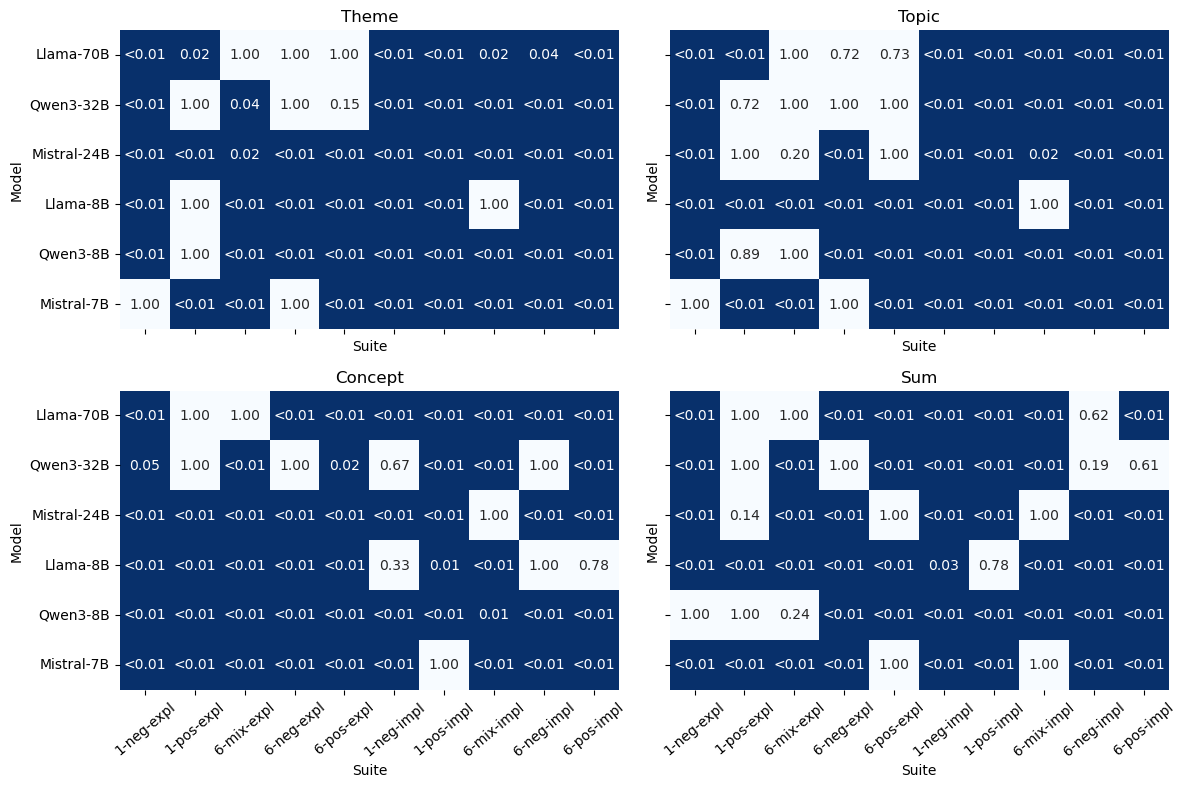

In [75]:
inner_idx = mcnemar_table.index.get_level_values(1)
labels = mcnemar_table.columns.get_level_values(0).unique()

drop_baseline = mcnemar_table[inner_idx != "0-non-expl"].reset_index()
hm = heatmap(drop_baseline)

#plt.savefig("./latex/images/mcnemar_significance_v2.png", bbox_inches="tight")

In [ ]:
path = "./data/mcnemar.json"

json = mcnemar_table.reset_index().to_json(
    None, #path,
    indent=4
)